In [1]:
import torch

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(device)

cuda


In [ ]:
"""
If you are getting DefaultCredentialsError, you need to set an enviorment variable for the path to your keyfile and restart your IDE.
(the below code should do that automatically once you download your key from Google Cloud Vision)
"""

import os
os.environ["GOOGLE_APPLICATION_CREDENTIALS"] = "C:/Projects/bitblind/ocr/resources/black-nucleus-488500-r9-55236df87f19.json"

from google.cloud import vision
vision.ImageAnnotatorClient()

In [4]:
def query(image_content):
    client = vision.ImageAnnotatorClient()

    image = vision.Image(content=image_content)

    response = client.document_text_detection(image=image)

    return response

In [5]:
def detect_text(response):
    if response.error.message:
        raise Exception(response.error.message)

    if not response.text_annotations:
        print("No text detected.")
        return

    # Full detected text
    print("Full text:")
    print(response.text_annotations[0].description)

    print("\nDetailed breakdown (word-level confidence):")
    for page in response.full_text_annotation.pages:
        for block in page.blocks:
            for paragraph in block.paragraphs:
                for word in paragraph.words:
                    word_text = "".join([s.text for s in word.symbols])
                    word_conf = getattr(word, "confidence", "N/A")
                    vertices = [(v.x, v.y) for v in word.bounding_box.vertices]
                    print(f"Word: {word_text}")
                    print(f"Confidence: {word_conf}")
                    print(f"Bounds: {vertices}")
                    # Optional: show symbol-level confidences
                    for symbol in word.symbols:
                        sym_conf = getattr(symbol, "confidence", "N/A")
                        print(f"  Symbol: {symbol.text}, Confidence: {sym_conf}")
                    print("-" * 40)

In [7]:
# Query for an image file
with open("../resources/example_data/test_image.png", "rb") as image_file:
    content = image_file.read()


response = query(content)

In [ ]:
detect_text(response)

Full text:
SMILE

Detailed breakdown (word-level confidence):
Word: SMILE
Confidence: 0.9912137389183044
Bounds: [(53, 54), (243, 55), (243, 106), (53, 105)]
  Symbol: S, Confidence: 0.9852168560028076
  Symbol: M, Confidence: 0.9909905791282654
  Symbol: I, Confidence: 0.9939791560173035
  Symbol: L, Confidence: 0.9944100379943848
  Symbol: E, Confidence: 0.991472065448761
----------------------------------------


In [106]:
import numpy as np
from PIL import Image, ImageDraw, ImageFont
import random

def load_images_as_arrays(folder_path):
    """
    Loads all images from a folder into a list of NumPy arrays (RGB).
    
    Args:
        folder_path (str): Path to directory containing images.
    
    Returns:
        List[np.ndarray]: List of image arrays.
    """
    image_arrays = []

    valid_exts = (".png", ".jpg", ".jpeg", ".bmp", ".tiff", ".webp")

    for filename in sorted(os.listdir(folder_path)):
        if filename.lower().endswith(valid_exts):
            file_path = os.path.join(folder_path, filename)
            try:
                with Image.open(file_path) as img:
                    img = img.convert("RGB")  # ensure consistent 3-channel format
                    image_arrays.append(np.array(img))
            except Exception as e:
                print(f"Skipping {filename}: {e}")

    return image_arrays

def generate_text_images(text_list,
                         output_folder="generated_images",
                         image_size=(400, 400)):
    """
    Generate one image per string in text_list with a random
    colored background and centered text.

    Args:
        text_list (list[str]): Strings to place on images.
        output_folder (str): Where to save images.
        image_size (tuple): (width, height)
    """

    os.makedirs(output_folder, exist_ok=True)

    try:
        font = ImageFont.truetype("arial.ttf", 40)
    except:
        font = ImageFont.load_default()

    for i, text in enumerate(text_list):

        # Random background color
        bg_color = tuple(random.randint(0, 255) for _ in range(3))

        # Create image
        img = Image.new("RGB", image_size, bg_color)
        draw = ImageDraw.Draw(img)

        # Calculate centered position
        bbox = draw.textbbox((0, 0), text, font=font)
        text_width = bbox[2] - bbox[0]
        text_height = bbox[3] - bbox[1]

        position = (
            (image_size[0] - text_width) // 2,
            (image_size[1] - text_height) // 2
        )

        # White text
        draw.text(position, text, fill=(255, 255, 255), font=font)

        # Safe filename
        safe_text = "".join(c for c in text if c.isalnum() or c in (" ", "_")).rstrip()
        filename = f"{i+1:04d}_{safe_text.replace(' ', '_')}.png"

        img.save(os.path.join(output_folder, filename))

    print(f"Generated {len(text_list)} images in '{output_folder}'")

In [6]:
import Levenshtein

def normalize_text(text):
    return ''.join(c.lower() for c in text if c.isalnum())

def extract_prediction(response):
    """
    Extract:
        full_text (string)
        mean_word_conf (float)
        mean_symbol_conf (float)
        word_count (int)
    From Google Vision protobuf response object.
    """

    # ---- Handle API error ----
    if response.error.message:
        return "", 0.0, 0.0, 0

    # ---- Full text ----
    if not response.text_annotations:
        return "", 0.0, 0.0, 0

    full_text = response.text_annotations[0].description.strip()

    word_confs = []
    symbol_confs = []
    word_count = 0

    # Walk protobuf structure
    for page in response.full_text_annotation.pages:
        for block in page.blocks:
            for paragraph in block.paragraphs:
                for word in paragraph.words:
                    
                    word_count += 1

                    # Word confidence
                    word_conf = getattr(word, "confidence", 0.0)
                    word_confs.append(word_conf)

                    # Symbol confidence
                    for symbol in word.symbols:
                        sym_conf = getattr(symbol, "confidence", 0.0)
                        symbol_confs.append(sym_conf)

    mean_word_conf = (
        sum(word_confs) / len(word_confs)
        if word_confs else 0.0
    )

    mean_symbol_conf = (
        sum(symbol_confs) / len(symbol_confs)
        if symbol_confs else 0.0
    )

    return full_text, mean_word_conf, mean_symbol_conf, word_count

def compute_loss(pred_text,
                 truth_text,
                 mean_symbol_conf,
                 word_count,
                 alpha=0.5,
                 beta=0.5,
                 max_clip=2.5):

    pred_norm = normalize_text(pred_text)
    truth_norm = normalize_text(truth_text)

    if len(truth_norm) == 0:
        ned = 1.0
    else:
        ned = Levenshtein.distance(pred_norm, truth_norm) / len(truth_norm)

    # Encourage confidence drop
    conf_term = 1.0 - mean_symbol_conf

    # Encourage detection collapse
    detection_term = 1.0 if word_count == 0 else 0.0

    loss = ned + alpha * conf_term + beta * detection_term

    return min(loss, max_clip)

In [31]:
pred_text, mean_word_conf, mean_symbol_conf, word_count = extract_prediction(response)

compute_loss(pred_text, "SMILE", mean_symbol_conf, word_count)

0.004393130540847778

In [7]:
class FourierOverlay(torch.nn.Module):
    def __init__(self, height, width, num_freq=40, max_freq=4):
        super().__init__()
        self.height = height
        self.width = width
        self.num_freq = num_freq
        
        self.coeffs = torch.nn.Parameter(
            torch.zeros(num_freq)
        )
        
        xs = torch.linspace(0, 1, width)
        ys = torch.linspace(0, 1, height)
        grid_x, grid_y = torch.meshgrid(xs, ys, indexing='xy')
        
        basis = []
        for _ in range(num_freq):
            fx = np.random.randint(1, max_freq)
            fy = np.random.randint(1, max_freq)
            phase = np.random.rand() * 2 * np.pi
            
            phi = torch.sin(2*np.pi*fx*grid_x + phase) + \
                  torch.cos(2*np.pi*fy*grid_y + phase)
            
            basis.append(phi)
        
        self.register_buffer("basis", torch.stack(basis))

    def forward(self):
        overlay = torch.sum(
            self.coeffs.view(-1,1,1) * self.basis,
            dim=0
        )
        overlay = overlay / (overlay.abs().max() + 1e-8)
        return overlay

In [72]:
def apply_overlay(image_np, overlay, epsilon=0.08):
    img = torch.tensor(image_np / 255.0).float()
    
    if img.ndim == 3:  # RGB
        overlay_rgb = overlay.unsqueeze(0).repeat(3,1,1)
    else:
        overlay_rgb = overlay.unsqueeze(0)
    
    perturbed = img + epsilon * overlay_rgb
    perturbed = torch.clamp(perturbed, 0, 1)
    
    return (perturbed.numpy() * 255).astype(np.uint8)

In [9]:
import cv2

def tensor_to_png_bytes(tensor):
    if tensor.shape[0] == 3:
        tensor = tensor.permute(1, 2, 0)

    img_uint8 = (tensor.detach().cpu().numpy() * 255).astype(np.uint8)
    success, encoded = cv2.imencode(".png", img_uint8)
    return encoded.tobytes()

In [76]:
def evaluate_batch(model, images, truths, epsilon=0.08):

    overlay = model()                  # (H, W)
    overlay = overlay.unsqueeze(-1)    # (H, W, 1)
    overlay_rgb = overlay.repeat(1, 1, 3)  # (H, W, 3)

    total_loss = 0.0
    count = 0

    for img_np, truth in zip(images, truths):

        img_np = torch.from_numpy(img_np).float() / 255.0  # HWC

        perturbed = img_np + epsilon * overlay_rgb
        perturbed = torch.clamp(perturbed, 0, 1)

        image_bytes = tensor_to_png_bytes(perturbed)
        response = query(image_bytes)

        pred_text, word_conf, symbol_conf, word_count = extract_prediction(response)

        loss = compute_loss(
            pred_text,
            truth,
            mean_symbol_conf=symbol_conf,
            word_count=word_count
        )

        total_loss += loss
        count += 1

    return total_loss / max(count, 1)

In [75]:
def nes_step(model,
             images,
             truths,
             sigma=0.08,
             lr=0.05,
             samples=20,
             epsilon=0.08):

    grad = torch.zeros_like(model.coeffs)

    base_coeffs = model.coeffs.data.clone()

    for _ in range(samples):

        u = torch.randn_like(model.coeffs)
        u = u / (u.norm() + 1e-8)

        # + direction
        model.coeffs.data = base_coeffs + sigma * u
        loss_pos = evaluate_batch(model, images, truths, epsilon)

        # - direction
        model.coeffs.data = base_coeffs - sigma * u
        loss_neg = evaluate_batch(model, images, truths, epsilon)

        grad += (loss_pos - loss_neg) * u

    grad /= (2 * sigma * samples)

    # Restore base
    model.coeffs.data = base_coeffs

    # Update (maximize loss)
    model.coeffs.data += lr * grad

    # Prevent explosion
    model.coeffs.data.clamp_(-3.0, 3.0)

    return grad.norm().item()

In [108]:
#test_labels = ["Hello", "Open", "Data", "Privacy", "Computer"]
test_labels = [
    "algorithm",
    "adversarial",
    "encryption",
    "authentication",
    "confidential",
    "cybersecurity",
    "vulnerability",
    "misconfiguration",
    "information",
    "aggregation",
    "correlation",
    "abstraction"
]
generate_text_images(test_labels, output_folder="test_samples", image_size=(400, 400))

Generated 12 images in 'test_samples'


In [151]:
# Number of training epochs
STEPS = 50

# Size of the input images
HEIGHT = 400
WIDTH = 400

# Numbeer of tunable parameters in the perturbation model
NUM_FREQ = 60

SIGMA = 0.08

# Learning Rate of the model
LR = 0.03

SAMPLES_PER_NES = 10

# Maximum magnitude of perturbations
EPSILON = 0.25

model = FourierOverlay(height=HEIGHT, width=WIDTH, num_freq=NUM_FREQ)

In [129]:
from PIL import Image

img = Image.open("test_samples/03_test.jpg")

# Resize to 400x400
img_resized = img.resize((400, 400))

# Save or overwrite
img_resized.save("test_samples/03_test.png")

In [152]:
images = load_images_as_arrays("test_samples")
test_labels = ["You've been living in a dream world, Neo.", "adding subtitles to my photos to make them look like movie stills", "I'm kind of in between being shocked by the question,"]

for step in range(STEPS):
        grad_norm = nes_step(
        model,
        images,
        test_labels,
        sigma=SIGMA,
        lr=LR,
        samples=SAMPLES_PER_NES,
        epsilon=EPSILON
        )


        current_loss = evaluate_batch(model, images, test_labels, EPSILON)
        print(f"Step {step:03d} | Loss: {current_loss:.4f} | GradNorm: {grad_norm:.4f}")

Step 000 | Loss: 0.0400 | GradNorm: 0.0601
Step 001 | Loss: 0.0651 | GradNorm: 0.0535
Step 002 | Loss: 0.0859 | GradNorm: 0.0585
Step 003 | Loss: 0.0854 | GradNorm: 0.0535
Step 004 | Loss: 0.0777 | GradNorm: 0.0429
Step 005 | Loss: 0.0779 | GradNorm: 0.0747
Step 006 | Loss: 0.0660 | GradNorm: 0.0579
Step 007 | Loss: 0.0579 | GradNorm: 0.0469
Step 008 | Loss: 0.0397 | GradNorm: 0.0568
Step 009 | Loss: 0.0788 | GradNorm: 0.0632
Step 010 | Loss: 0.0945 | GradNorm: 0.0372
Step 011 | Loss: 0.0788 | GradNorm: 0.0749
Step 012 | Loss: 0.0661 | GradNorm: 0.0456
Step 013 | Loss: 0.0887 | GradNorm: 0.0414
Step 014 | Loss: 0.0671 | GradNorm: 0.0763
Step 015 | Loss: 0.0843 | GradNorm: 0.0525
Step 016 | Loss: 0.0658 | GradNorm: 0.0617
Step 017 | Loss: 0.0690 | GradNorm: 0.0511
Step 018 | Loss: 0.0683 | GradNorm: 0.0609
Step 019 | Loss: 0.0669 | GradNorm: 0.0557
Step 020 | Loss: 0.0669 | GradNorm: 0.0525
Step 021 | Loss: 0.0675 | GradNorm: 0.0560
Step 022 | Loss: 0.0727 | GradNorm: 0.0461
Step 023 | 

In [153]:
torch.save({
    "model_state_dict": model.state_dict(),
}, "attack_checkpoint.pt")

In [154]:
overlay = model().detach().cpu()

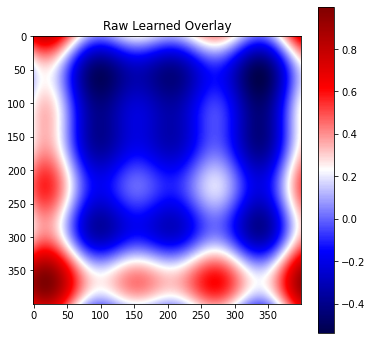

In [155]:
import matplotlib.pyplot as plt

plt.figure(figsize=(6,6))
plt.imshow(overlay.numpy(), cmap="seismic")
plt.colorbar()
plt.title("Raw Learned Overlay")
plt.show()

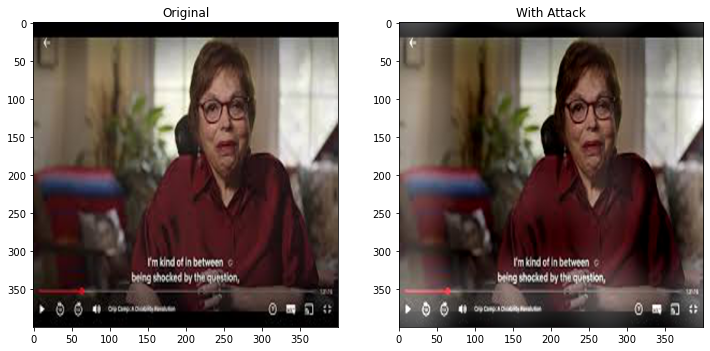

In [ ]:
img = torch.from_numpy(images[0]).float() / 255.0
overlay_rgb = overlay.unsqueeze(-1).repeat(1,1,3)

perturbed = torch.clamp(img + 0.4 * overlay_rgb, 0, 1)

plt.figure(figsize=(12,6))

plt.subplot(1,2,1)
plt.imshow(img.numpy())
plt.title("Original")

plt.subplot(1,2,2)
plt.imshow(perturbed.numpy())
plt.title("With Attack")

plt.show()

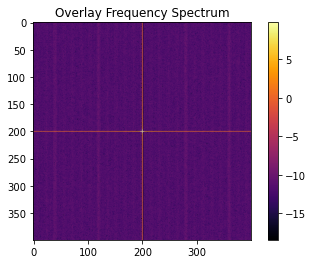

In [157]:
fft = torch.fft.fftshift(torch.fft.fft2(overlay))
magnitude = torch.log(torch.abs(fft) + 1e-8)

plt.imshow(magnitude.numpy(), cmap="inferno")
plt.title("Overlay Frequency Spectrum")
plt.colorbar()
plt.show()

In [158]:
a1 = query(tensor_to_png_bytes(perturbed))
a2 = query(tensor_to_png_bytes(img))

In [159]:
print(detect_text(a1))
print(detect_text(a2))

Full text:
I'm kind of in between
being shocked by the question,
525

Detailed breakdown (word-level confidence):
Word: I'm
Confidence: 0.7374550700187683
Bounds: [(148, 308), (165, 308), (165, 322), (148, 322)]
  Symbol: I, Confidence: 0.6342694163322449
  Symbol: ', Confidence: 0.6685367226600647
  Symbol: m, Confidence: 0.9095590114593506
----------------------------------------
Word: kind
Confidence: 0.8940615057945251
Bounds: [(164, 308), (185, 308), (185, 322), (164, 322)]
  Symbol: k, Confidence: 0.8524369597434998
  Symbol: i, Confidence: 0.8621898293495178
  Symbol: n, Confidence: 0.9294866323471069
  Symbol: d, Confidence: 0.9321325421333313
----------------------------------------
Word: of
Confidence: 0.9185345768928528
Bounds: [(188, 308), (199, 308), (199, 322), (188, 322)]
  Symbol: o, Confidence: 0.9436475038528442
  Symbol: f, Confidence: 0.8934216499328613
----------------------------------------
Word: in
Confidence: 0.8909151554107666
Bounds: [(199, 308), (209, 308), 

In [32]:
img = torch.from_numpy(images[0]).float() / 255.0
overlay = model().unsqueeze(-1).repeat(1,1,3)

u = torch.randn_like(overlay)
overlay_pos = overlay + 0.1 * u
overlay_neg = overlay - 0.1 * u

pert_pos = torch.clamp(img + 0.2 * overlay_pos, 0,1)
pert_neg = torch.clamp(img + 0.2 * overlay_neg, 0,1)

print("Overlay pos min/max:", overlay_pos.min(), overlay_pos.max())
print("Perturbed pos min/max:", pert_pos.min(), pert_pos.max())

resp_pos = query(tensor_to_png_bytes(pert_pos))
resp_neg = query(tensor_to_png_bytes(pert_neg))

pred_text, word_conf, symbol_conf, word_count = extract_prediction(resp_pos)
L_pos = compute_loss(
    pred_text,
    test_labels[0],
    mean_symbol_conf=symbol_conf,
    word_count=word_count
)

pred_text, word_conf, symbol_conf, word_count = extract_prediction(resp_neg)
L_neg = compute_loss(
    pred_text,
    test_labels[0],
    mean_symbol_conf=symbol_conf,
    word_count=word_count
)

print("L_pos:", L_pos, "L_neg:", L_neg, "Diff:", L_pos - L_neg)

Overlay pos min/max: tensor(-1.1241, grad_fn=<MinBackward1>) tensor(1.2822, grad_fn=<MaxBackward1>)
Perturbed pos min/max: tensor(0., grad_fn=<MinBackward1>) tensor(1., grad_fn=<MaxBackward1>)
L_pos: 1.229701162212425 L_neg: 1.2268005394273336 Diff: 0.0029006227850914
